AttributeError: 'numpy.ndarray' object has no attribute 'yaxis'

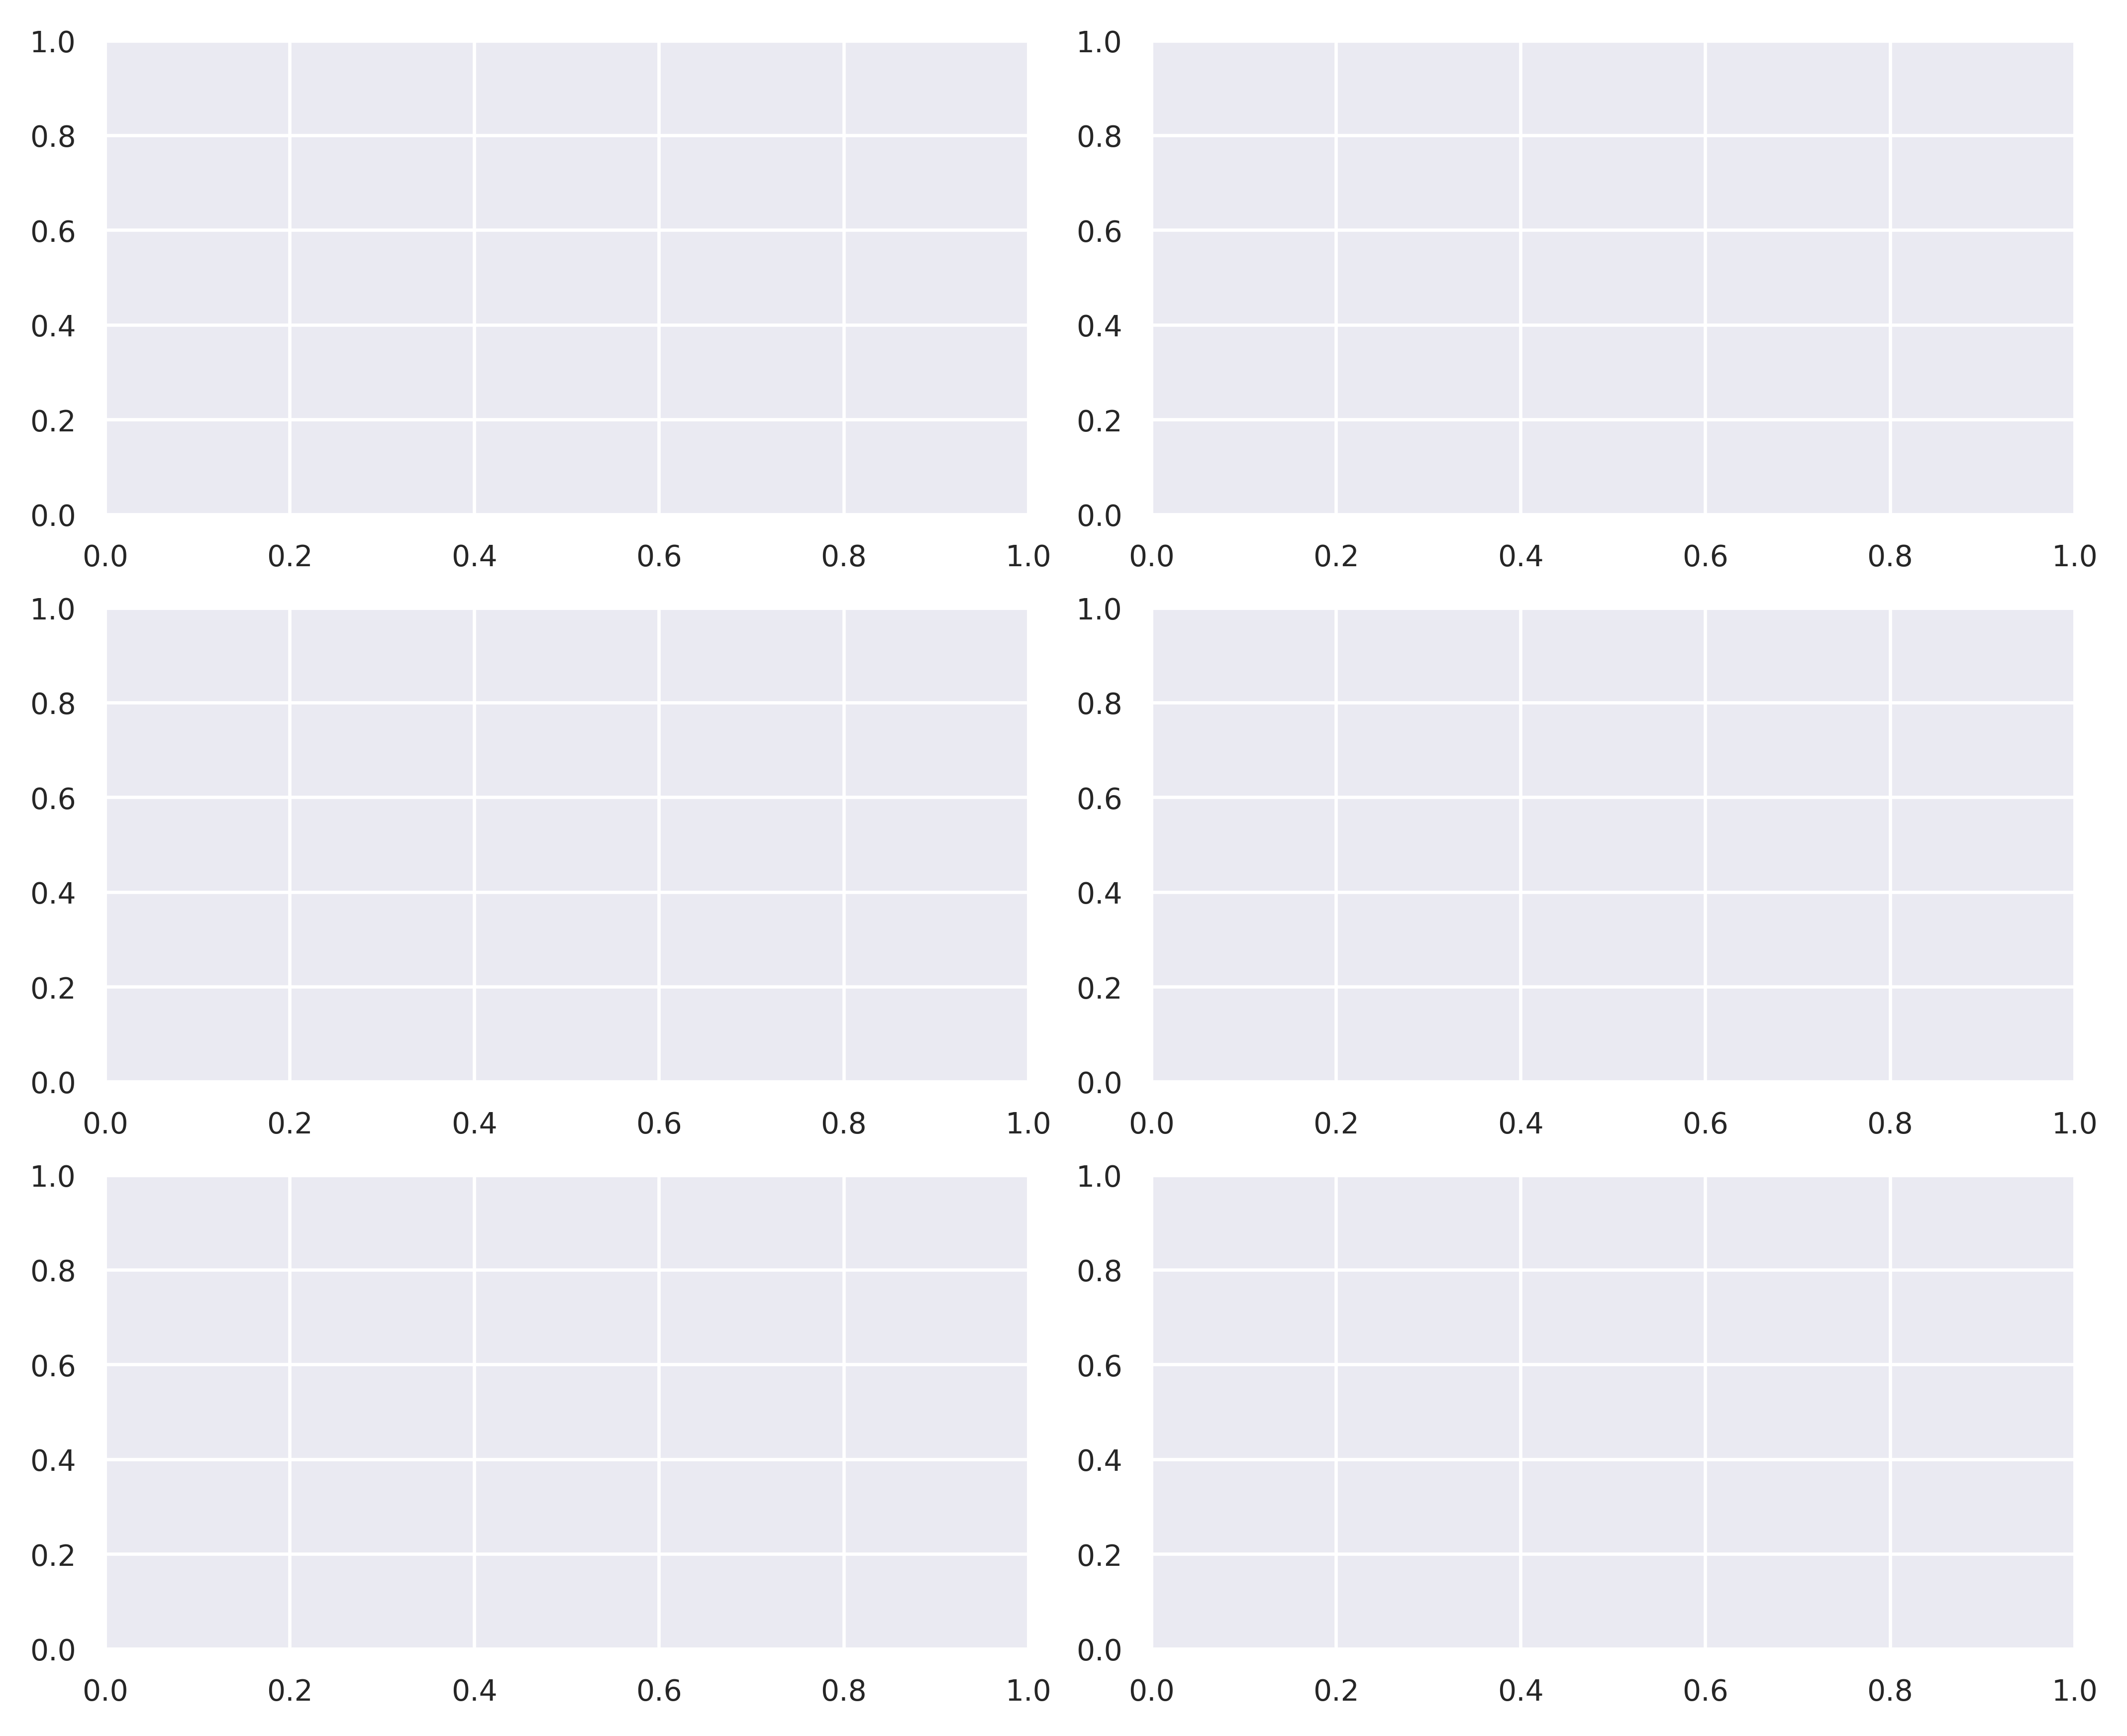

In [6]:
import torch
import os
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
torch.serialization.add_safe_globals([defaultdict, list])
# plt.style.use('ggplot')
# plt.style.use('default')
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

experiments = []
# Pretraining experiment
runs_pt = ['accelformer_nodecomp_sleep_3132481', 'accelformer_sleep_3133161', 'mae_scg_e26_sleep_3206888', 'mae_breath_e20_sleep_3107270'][::-1]
labels_pt = ['Supervised', 'Supervised w. decomp', 'SCG-MAE', 'RWM-MAE\n(AcceleRest)'][::-1]
best_epochs_pt = [-1, -1, -1, -1]
experiments.append(('Models', runs_pt, labels_pt))#, best_epochs_pt))
# All day vs nights
runs_pt = ['mae_breath_e20_sleep_3107270', 'mae_bwm_nights_e40_3730745']
labels_pt = ['All Day\n(AcceleRest)', 'Nights Only']
best_epochs_pt = [-1, -1]
experiments.append(('Data', runs_pt, labels_pt))#, best_epochs_pt))
# Finetuning strategies experiment
runs_ft = ['mae_breath_e20_sleep_3107270', 'mae_bwm_mlp_3591247','mae_bwm_lstm_comp_3591380','mae_breath_e20_sleep_lstm_3109767']
labels_ft = ['Linear', 'MLP', 'LSTM-C', 'LSTM-F']
best_epochs_ft = [74, 11, 41, 3]
experiments.append(('Classifiers', runs_ft, labels_ft))#, best_epochs_ft))

# palette = ['firebrick', 'darkorchid', 'gold', 'navy']

group = 'wassed'
# metrics = ['macro_auc','wake_auc','light_auc','deep_auc', 'rem_auc']
metrics = ['macro_f1','wake_f1','light_f1','deep_f1', 'rem_f1']
results_list = []

fig, axes = plt.subplots(3,2,dpi=600,figsize=(7.01,5.7),layout='constrained')
for e, (name, runs, labels) in enumerate(experiments):
    # axes[e,0].set_title(name)#, pad=18)
    fold_macro_dfs = []
    results = defaultdict(list)
    for metric in metrics:
        for i, run in enumerate(runs):
            cv_path = f'/oak/stanford/groups/mignot/projects/actigraphy_fm/runs/{group}/finetune_cv/{run}/'
            fold_metrics = []
            for fold in os.scandir(cv_path):
                if fold.is_dir():
                    fold_metric = torch.load(os.path.join(fold.path, 'validation_metrics.pt'), map_location='cpu')
                    fold_metrics.append(fold_metric)

            metric_array = []
            metrics_dict = {} 
            for f, fold in enumerate(fold_metrics):
                metric_array.append(fold[f'validation/{metric}'])
                metrics_dict[f'fold_{f}'] = fold[f'validation/{metric}']

  
            metric_array = np.array(metric_array)
            mean = metric_array.mean(axis=0)
            std = metric_array.std(axis=0)
            if name == 'Classifiers' and 'macro' in metrics:
                best_epoch = np.argmax(mean)
            else:
                best_epoch = -1

            epoch_mean = mean[best_epoch]
            epoch_std = std[best_epoch]
            # print(f'{labels[i]} {metric} epoch {best_epoch} (Mean ± SD): {round(epoch_mean,3)} ± {round(epoch_std,3)}')
            results_ = list(metric_array[:,best_epoch].ravel())
            results['model'].extend(np.repeat(labels[i], len(results_)))
            results['metric'].extend(np.repeat(metric, len(results_)))
            results['fold'].extend(np.arange(len(results_)))
            results['values'].extend(results_)


            if 'macro' in metric:
                epochs = np.arange(len(mean))
                fold_metrics_df = pd.DataFrame(metrics_dict)
                fold_metrics_df['epochs'] = epochs
                fold_metrics_df = fold_metrics_df.melt(id_vars = ['epochs'])
                fold_metrics_df['run'] = labels[i]
                fold_macro_dfs.append(fold_metrics_df)
                # axes[e,1].plot(x,mean, label=labels[i])#, zorder=3)
                # axes[e,1].fill_between(x, mean-std, mean+std, alpha=0.5)#,zorder=2)
                
                # axes[1,e].legend()
    fold_macro_df = pd.concat(fold_macro_dfs)
    ax = sns.lineplot(fold_macro_df, x='epochs', y='value', hue='run', ax=axes[e,1], palette='Set1')
    ax.legend(title='', ncols=2, bbox_to_anchor=(0,1),loc='lower left', fontsize=7)#, mode='expand')
    ax.set_xticks(np.arange(0, len(fold_macro_df['epochs'].unique())+1, 15))
    ax.set_xlabel('')
    ax.set_ylabel('Macro F1')
    axes[-1,1].set_xlabel('Epochs')
    ax.grid()

    
    ax = sns.barplot(pd.DataFrame(results),x='metric',y='values', hue='model', ax=axes[e,0], palette='Set1')
    ax.set_xticks(ticks=np.arange(5) ,labels=['Macro', 'Wake', 'Light', 'Deep', 'REM'])
    ax.set_xlabel('')
    ax.set_ylabel('F1')
    ax.legend(title='', ncols=2, bbox_to_anchor=(0,1),loc='lower left', fontsize=7)#, mode='expand')
    ax.grid()
    # ax.set_ylim(0.5,1)
    results_list.append(pd.DataFrame(results))

axes = axes.ravel()
for i, ax in enumerate(axes):
    # Add alphabetic ordering
    sub = 0.1 if i in [2,3] else 0
    ax.annotate(
        f'{chr(97+i)}',
        xy=(-0.09, 1.22 - sub), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize', fontweight='bold',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.grid()

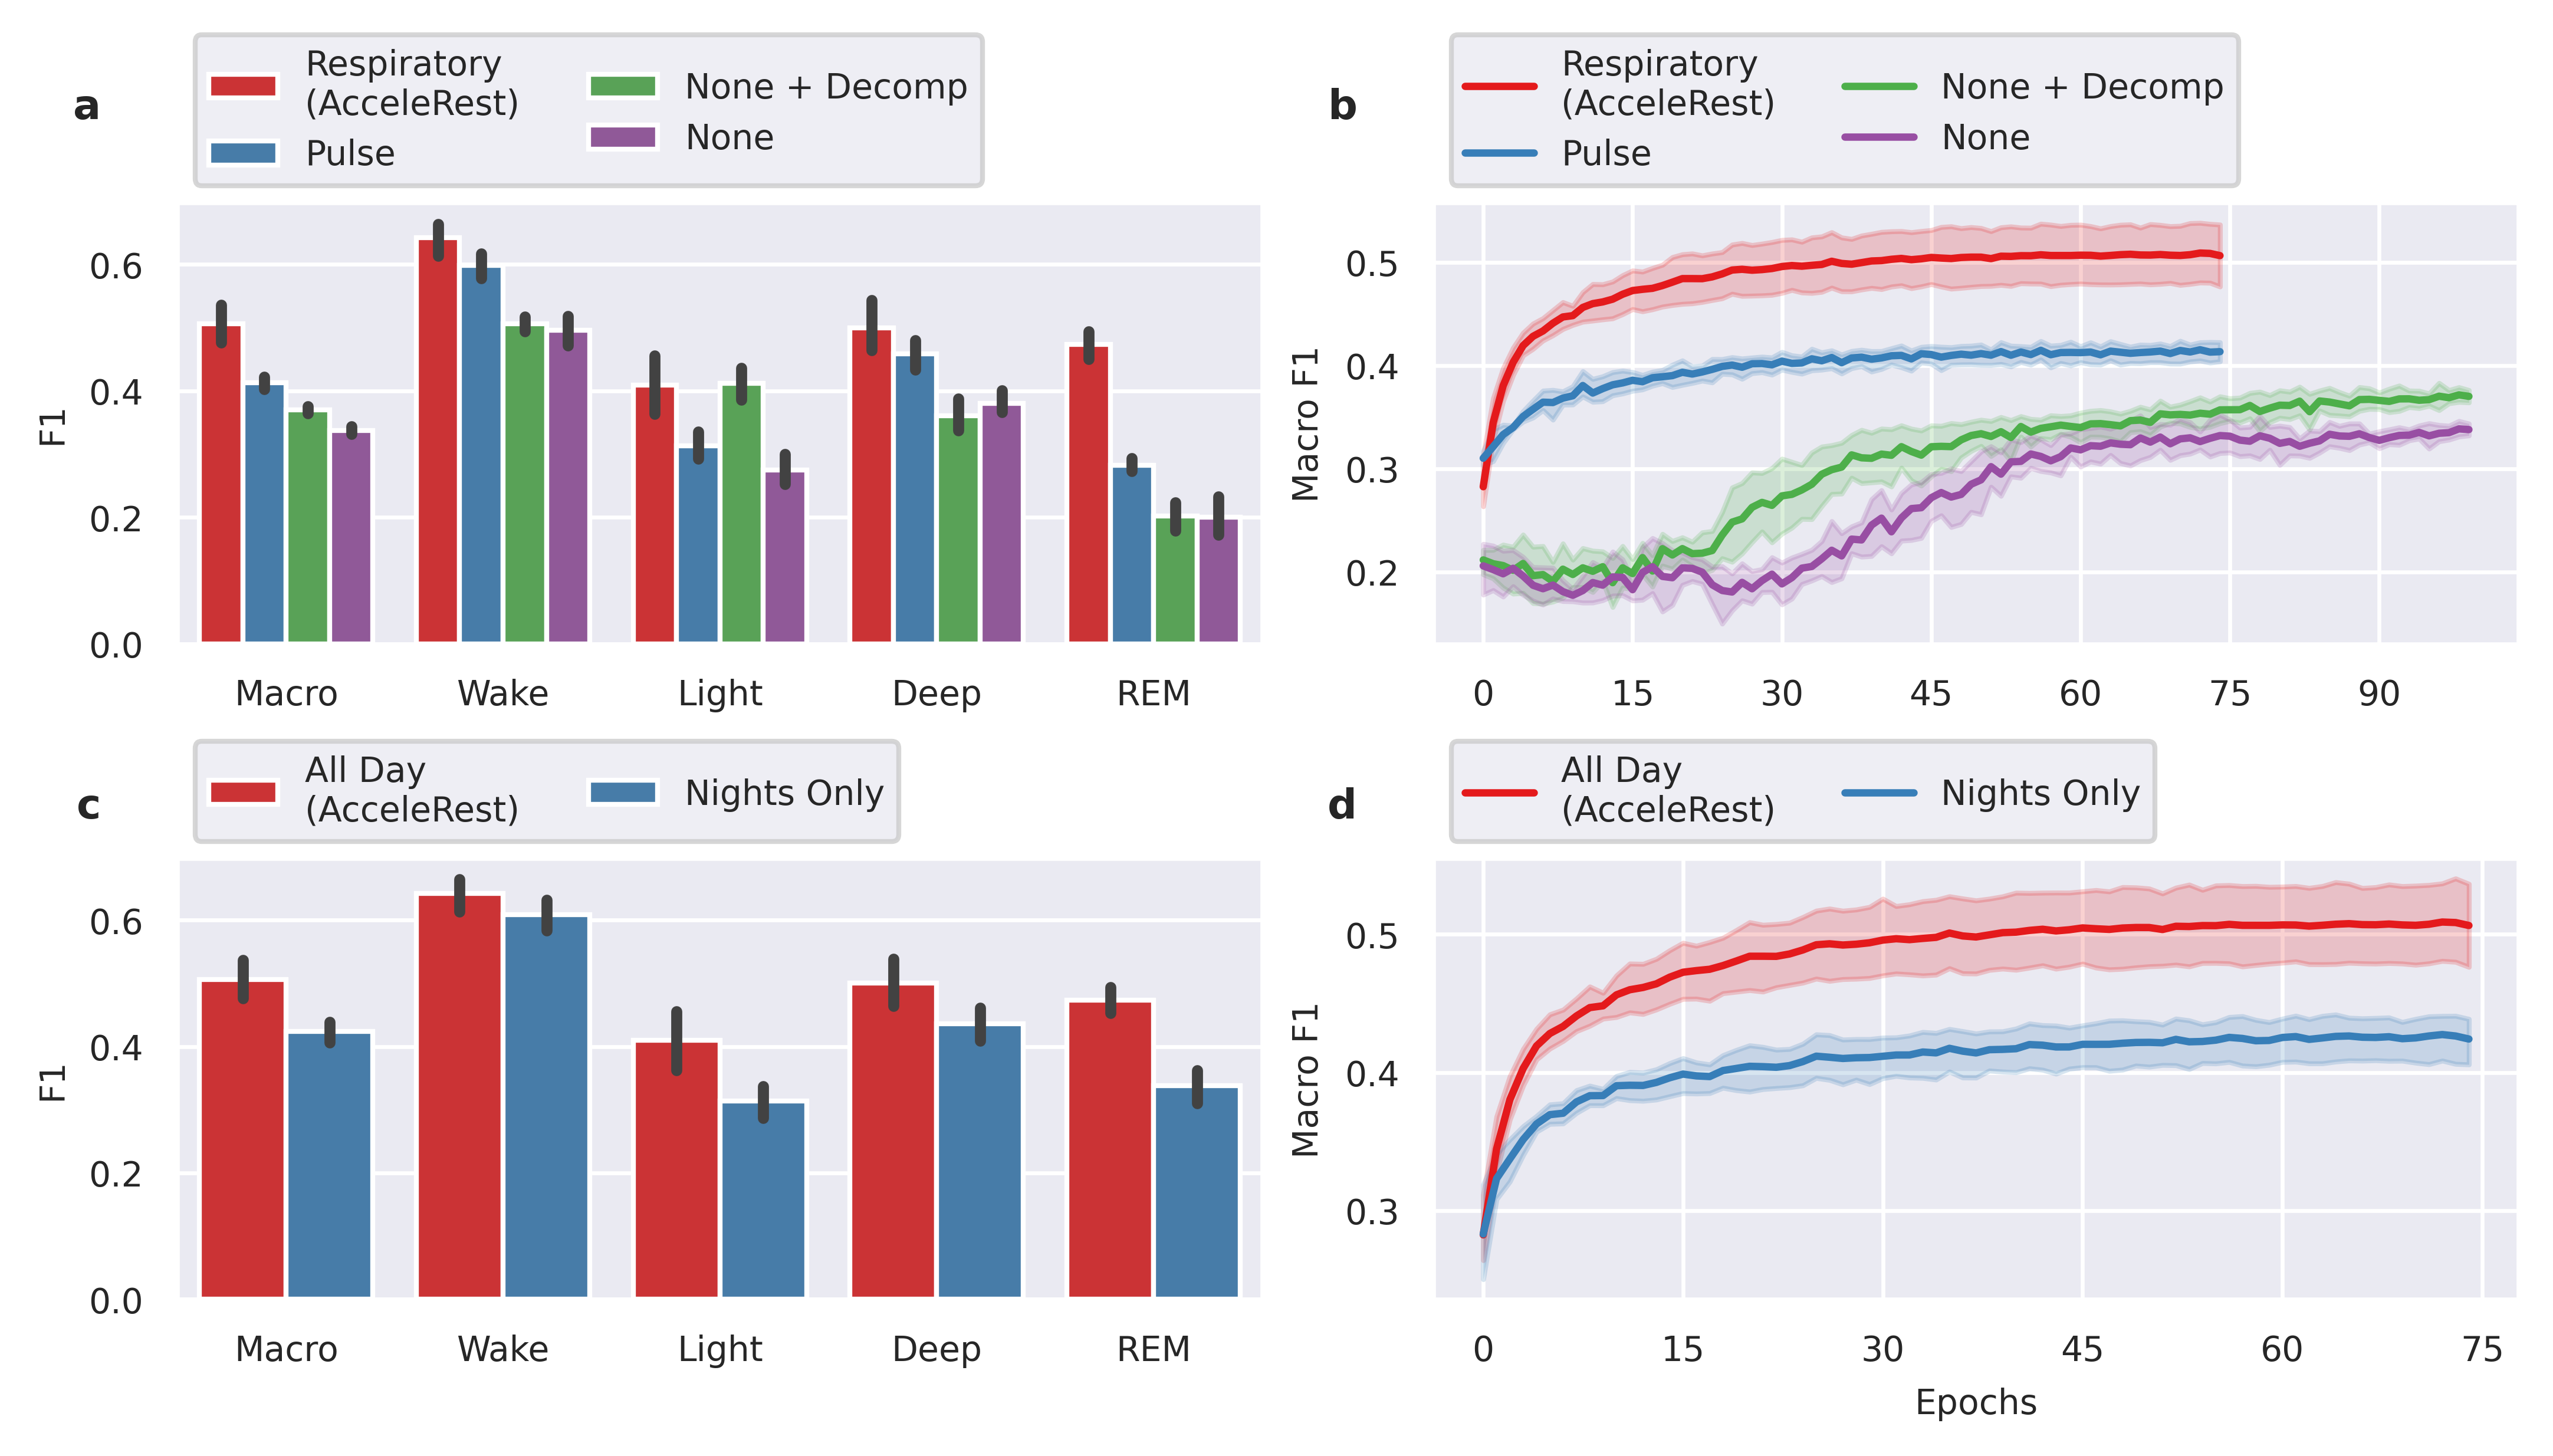

In [4]:
import torch
import os
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
torch.serialization.add_safe_globals([defaultdict, list])
# plt.style.use('ggplot')
# plt.style.use('default')
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

experiments = []
# Pretraining experiment
runs_pt = ['accelformer_nodecomp_sleep_3132481', 'accelformer_sleep_3133161', 'mae_scg_e26_sleep_3206888', 'mae_breath_e20_sleep_3107270'][::-1]
labels_pt = ['None', 'None + Decomp', 'Pulse', 'Respiratory\n(AcceleRest)'][::-1]
best_epochs_pt = [-1, -1, -1, -1]
experiments.append(('Models', runs_pt, labels_pt))#, best_epochs_pt))
# All day vs nights
runs_pt = ['mae_breath_e20_sleep_3107270', 'mae_bwm_nights_e40_3730745']
labels_pt = ['All Day\n(AcceleRest)', 'Nights Only']
best_epochs_pt = [-1, -1]
experiments.append(('Data', runs_pt, labels_pt))#, best_epochs_pt))
# # Finetuning strategies experiment
# runs_ft = ['mae_breath_e20_sleep_3107270', 'mae_bwm_mlp_3591247','mae_bwm_lstm_comp_3591380','mae_breath_e20_sleep_lstm_3109767']
# labels_ft = ['Linear', 'MLP', 'LSTM-C', 'LSTM-F']
# best_epochs_ft = [74, 11, 41, 3]
# experiments.append(('Classifiers', runs_ft, labels_ft))#, best_epochs_ft))

# palette = ['firebrick', 'darkorchid', 'gold', 'navy']

group = 'wassed'
# metrics = ['macro_auc','wake_auc','light_auc','deep_auc', 'rem_auc']
metrics = ['macro_f1','wake_f1','light_f1','deep_f1', 'rem_f1']
results_list = []

fig, axes = plt.subplots(2,2,dpi=600,figsize=(7.1,4),layout='constrained')
for e, (name, runs, labels) in enumerate(experiments):
    # axes[e,0].set_title(name)#, pad=18)
    fold_macro_dfs = []
    results = defaultdict(list)
    for metric in metrics:
        for i, run in enumerate(runs):
            cv_path = f'/oak/stanford/groups/mignot/projects/actigraphy_fm/runs/{group}/finetune_cv/{run}/'
            fold_metrics = []
            for fold in os.scandir(cv_path):
                if fold.is_dir():
                    fold_metric = torch.load(os.path.join(fold.path, 'validation_metrics.pt'), map_location='cpu')
                    fold_metrics.append(fold_metric)

            metric_array = []
            metrics_dict = {} 
            for f, fold in enumerate(fold_metrics):
                metric_array.append(fold[f'validation/{metric}'])
                metrics_dict[f'fold_{f}'] = fold[f'validation/{metric}']

  
            metric_array = np.array(metric_array)
            mean = metric_array.mean(axis=0)
            std = metric_array.std(axis=0)
            if name == 'Classifiers' and 'macro' in metrics:
                best_epoch = np.argmax(mean)
            else:
                best_epoch = -1

            epoch_mean = mean[best_epoch]
            epoch_std = std[best_epoch]
            # print(f'{labels[i]} {metric} epoch {best_epoch} (Mean ± SD): {round(epoch_mean,3)} ± {round(epoch_std,3)}')
            results_ = list(metric_array[:,best_epoch].ravel())
            results['model'].extend(np.repeat(labels[i], len(results_)))
            results['metric'].extend(np.repeat(metric, len(results_)))
            results['fold'].extend(np.arange(len(results_)))
            results['values'].extend(results_)


            if 'macro' in metric:
                epochs = np.arange(len(mean))
                fold_metrics_df = pd.DataFrame(metrics_dict)
                fold_metrics_df['epochs'] = epochs
                fold_metrics_df = fold_metrics_df.melt(id_vars = ['epochs'])
                fold_metrics_df['run'] = labels[i]
                fold_macro_dfs.append(fold_metrics_df)
                # axes[e,1].plot(x,mean, label=labels[i])#, zorder=3)
                # axes[e,1].fill_between(x, mean-std, mean+std, alpha=0.5)#,zorder=2)
                
                # axes[1,e].legend()
    fold_macro_df = pd.concat(fold_macro_dfs)
    ax = sns.lineplot(fold_macro_df, x='epochs', y='value', hue='run', ax=axes[e,1], palette='Set1')
    ax.legend(title='', ncols=2, bbox_to_anchor=(0,1),loc='lower left', fontsize=7)#, mode='expand')
    ax.set_xticks(np.arange(0, len(fold_macro_df['epochs'].unique())+1, 15))
    ax.set_xlabel('')
    ax.set_ylabel('Macro F1')
    axes[-1,1].set_xlabel('Epochs')
    ax.grid()

    
    ax = sns.barplot(pd.DataFrame(results),x='metric',y='values', hue='model', ax=axes[e,0], palette='Set1')
    ax.set_xticks(ticks=np.arange(5) ,labels=['Macro', 'Wake', 'Light', 'Deep', 'REM'])
    ax.set_xlabel('')
    ax.set_ylabel('F1')
    ax.legend(title='', ncols=2, bbox_to_anchor=(0,1),loc='lower left', fontsize=7)#, mode='expand')
    ax.grid()
    # ax.set_ylim(0.5,1)
    results_list.append(pd.DataFrame(results))

axes = axes.ravel()
for i, ax in enumerate(axes):
    # Add alphabetic ordering
    sub = 0.1 if i in [2,3] else 0
    ax.annotate(
        f'{chr(97+i)}',
        xy=(-0.09, 1.22 - sub), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize', fontweight='bold',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.grid()

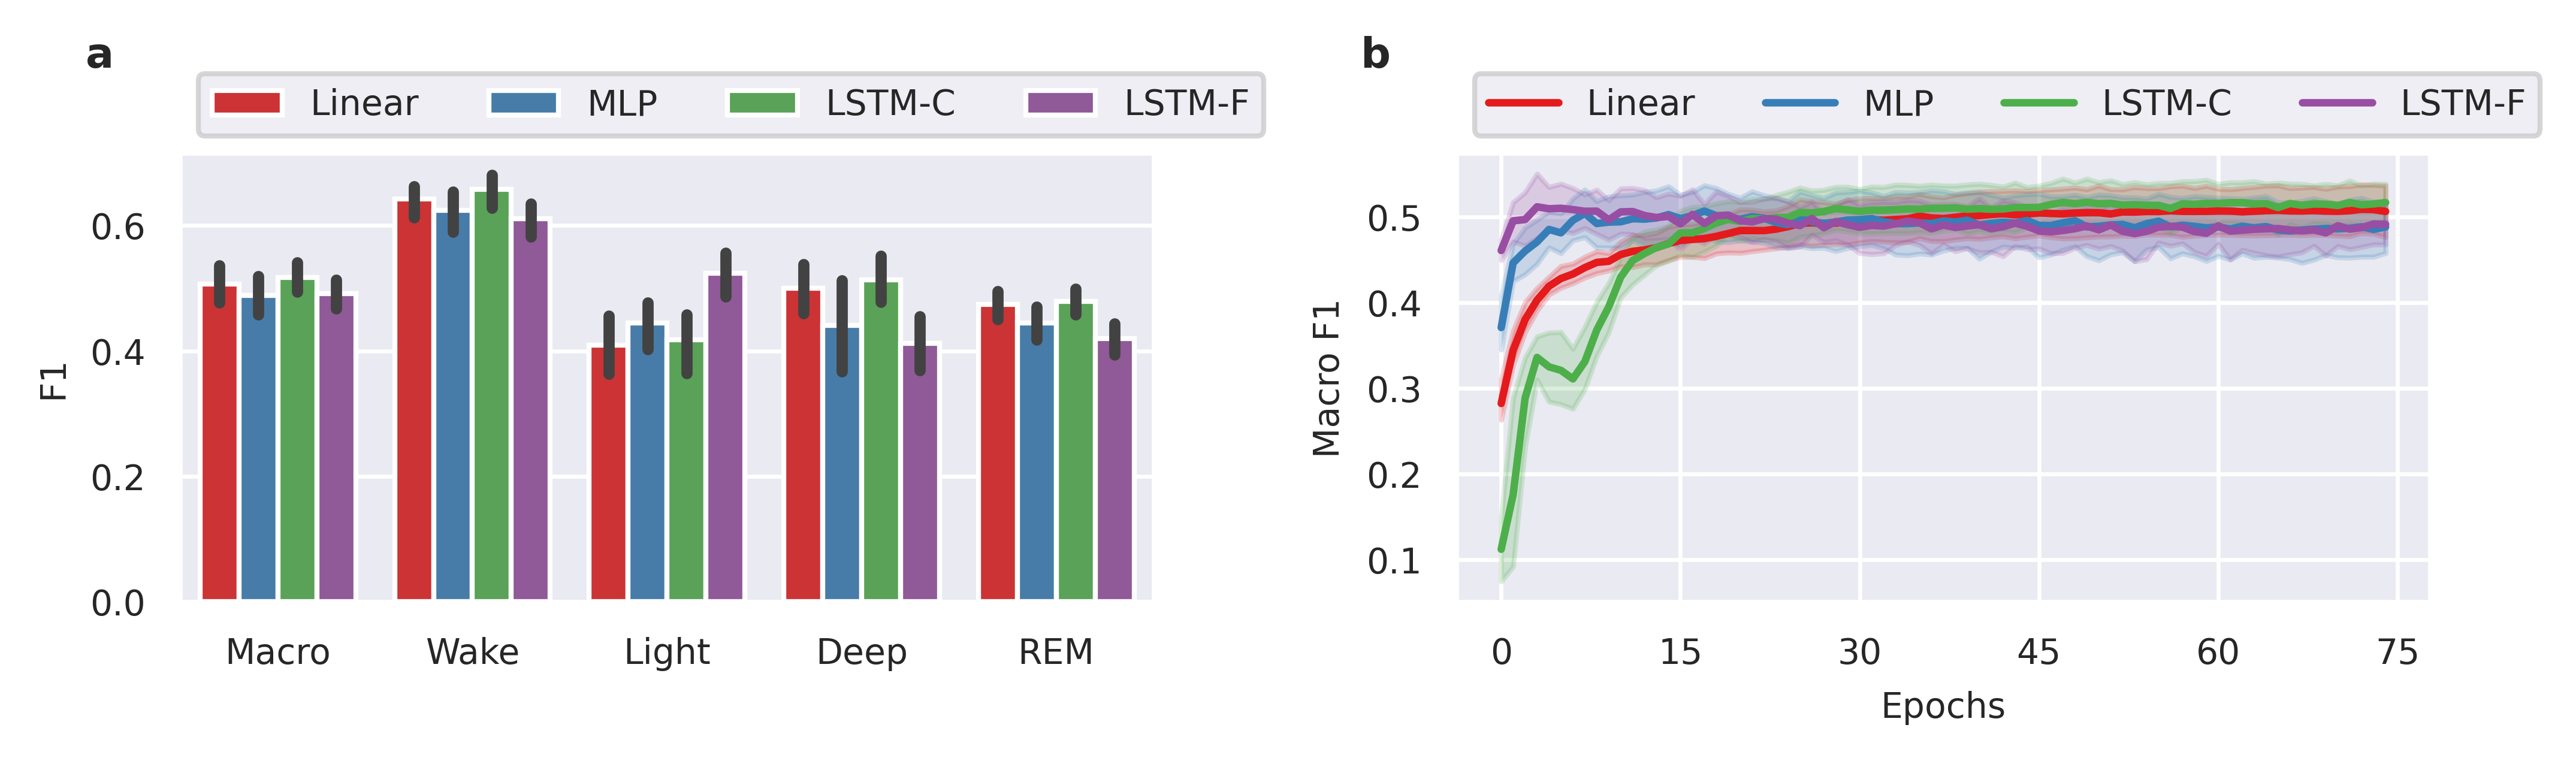

In [13]:

experiments = []
# # Pretraining experiment
# runs_pt = ['accelformer_nodecomp_sleep_3132481', 'accelformer_sleep_3133161', 'mae_scg_e26_sleep_3206888', 'mae_breath_e20_sleep_3107270'][::-1]
# labels_pt = ['None', 'None + Decomp', 'Pulse', 'Respiratory\n(AcceleRest)'][::-1]
# best_epochs_pt = [-1, -1, -1, -1]
# experiments.append(('Models', runs_pt, labels_pt))#, best_epochs_pt))
# # All day vs nights
# runs_pt = ['mae_breath_e20_sleep_3107270', 'mae_bwm_nights_e40_3730745']
# labels_pt = ['All Day\n(AcceleRest)', 'Nights Only']
# best_epochs_pt = [-1, -1]
# experiments.append(('Data', runs_pt, labels_pt))#, best_epochs_pt))
# Finetuning strategies experiment
runs_ft = ['mae_breath_e20_sleep_3107270', 'mae_bwm_mlp_3591247','mae_bwm_lstm_comp_3591380','mae_breath_e20_sleep_lstm_3109767']
labels_ft = ['Linear', 'MLP', 'LSTM-C', 'LSTM-F']
best_epochs_ft = [74, 11, 41, 3]
experiments.append(('Classifiers', runs_ft, labels_ft))#, best_epochs_ft))

# palette = ['firebrick', 'darkorchid', 'gold', 'navy']

group = 'wassed'
# metrics = ['macro_auc','wake_auc','light_auc','deep_auc', 'rem_auc']
metrics = ['macro_f1','wake_f1','light_f1','deep_f1', 'rem_f1']
results_list = []

fig, axes = plt.subplots(1,2,dpi=600,figsize=(7.1,2),layout='constrained')
for e, (name, runs, labels) in enumerate(experiments):
    # axes[e,0].set_title(name)#, pad=18)
    fold_macro_dfs = []
    results = defaultdict(list)
    for metric in metrics:
        for i, run in enumerate(runs):
            cv_path = f'/oak/stanford/groups/mignot/projects/actigraphy_fm/runs/{group}/finetune_cv/{run}/'
            fold_metrics = []
            for fold in os.scandir(cv_path):
                if fold.is_dir():
                    fold_metric = torch.load(os.path.join(fold.path, 'validation_metrics.pt'), map_location='cpu')
                    fold_metrics.append(fold_metric)

            metric_array = []
            metrics_dict = {} 
            for f, fold in enumerate(fold_metrics):
                metric_array.append(fold[f'validation/{metric}'])
                metrics_dict[f'fold_{f}'] = fold[f'validation/{metric}']

  
            metric_array = np.array(metric_array)
            mean = metric_array.mean(axis=0)
            std = metric_array.std(axis=0)
            if name == 'Classifiers' and 'macro' in metrics:
                best_epoch = np.argmax(mean)
            else:
                best_epoch = -1

            epoch_mean = mean[best_epoch]
            epoch_std = std[best_epoch]
            # print(f'{labels[i]} {metric} epoch {best_epoch} (Mean ± SD): {round(epoch_mean,3)} ± {round(epoch_std,3)}')
            results_ = list(metric_array[:,best_epoch].ravel())
            results['model'].extend(np.repeat(labels[i], len(results_)))
            results['metric'].extend(np.repeat(metric, len(results_)))
            results['fold'].extend(np.arange(len(results_)))
            results['values'].extend(results_)


            if 'macro' in metric:
                epochs = np.arange(len(mean))
                fold_metrics_df = pd.DataFrame(metrics_dict)
                fold_metrics_df['epochs'] = epochs
                fold_metrics_df = fold_metrics_df.melt(id_vars = ['epochs'])
                fold_metrics_df['run'] = labels[i]
                fold_macro_dfs.append(fold_metrics_df)
                # axes[e,1].plot(x,mean, label=labels[i])#, zorder=3)
                # axes[e,1].fill_between(x, mean-std, mean+std, alpha=0.5)#,zorder=2)
                
                # axes[1,e].legend()
    fold_macro_df = pd.concat(fold_macro_dfs)
    ax = sns.lineplot(fold_macro_df, x='epochs', y='value', hue='run', ax=axes[1], palette='Set1')
    ax.legend(title='', ncols=4, bbox_to_anchor=(0,1),loc='lower left', fontsize=7)#, mode='expand')
    ax.set_xticks(np.arange(0, len(fold_macro_df['epochs'].unique())+1, 15))
    ax.set_xlabel('')
    ax.set_ylabel('Macro F1')
    axes[-1].set_xlabel('Epochs')
    ax.grid()

    
    ax = sns.barplot(pd.DataFrame(results),x='metric',y='values', hue='model', ax=axes[0], palette='Set1')
    ax.set_xticks(ticks=np.arange(5) ,labels=['Macro', 'Wake', 'Light', 'Deep', 'REM'])
    ax.set_xlabel('')
    ax.set_ylabel('F1')
    ax.legend(title='', ncols=4, bbox_to_anchor=(0,1),loc='lower left', fontsize=7)#, mode='expand')
    ax.grid()
    # ax.set_ylim(0.5,1)
    results_list.append(pd.DataFrame(results))

axes = axes.ravel()
for i, ax in enumerate(axes):
    # Add alphabetic ordering
    sub = 0.1 if i in [2,3] else 0
    ax.annotate(
        f'{chr(97+i)}',
        xy=(-0.09, 1.22 - sub), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize', fontweight='bold',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.grid()

In [118]:
import itertools
from scipy.stats import ttest_rel

for i in range(len(results_list)):
    output = []
    df = results_list[i]
    for metric, g in df.groupby("metric"):
        # Pivot so rows=folds, cols=models
        wide = g.pivot(index="fold", columns="model", values="values")

        # Iterate over all pairs of models
        for m1, m2 in itertools.combinations(wide.columns, 2):
            vals1 = wide[m1].dropna()
            vals2 = wide[m2].dropna()

            # Align folds (important if some are missing)
            aligned = pd.concat([vals1, vals2], axis=1, join="inner").dropna()
            if aligned.shape[0] > 1:  # need at least 2 folds
                stat, pval = ttest_rel(aligned[m1], aligned[m2])
                output.append({
                    "metric": metric,
                    "model1": m1,
                    "model2": m2,
                    "t_stat": stat,
                    "p_value": pval
                })

    output_df = pd.DataFrame(output)
    mean_df = results_list[i].drop(columns=['fold']).groupby(['model', 'metric']).mean()
    sd_df = results_list[i].drop(columns=['fold']).groupby(['model', 'metric']).std()
    new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)

    name = experiments[i][0]
    output_df.to_csv(f'/oak/stanford/groups/mignot/projects/actigraphy_fm/results/ablations_{name}_stats.csv')
    new_df.to_csv(f'/oak/stanford/groups/mignot/projects/actigraphy_fm/results/ablations_{name}_results.csv')
